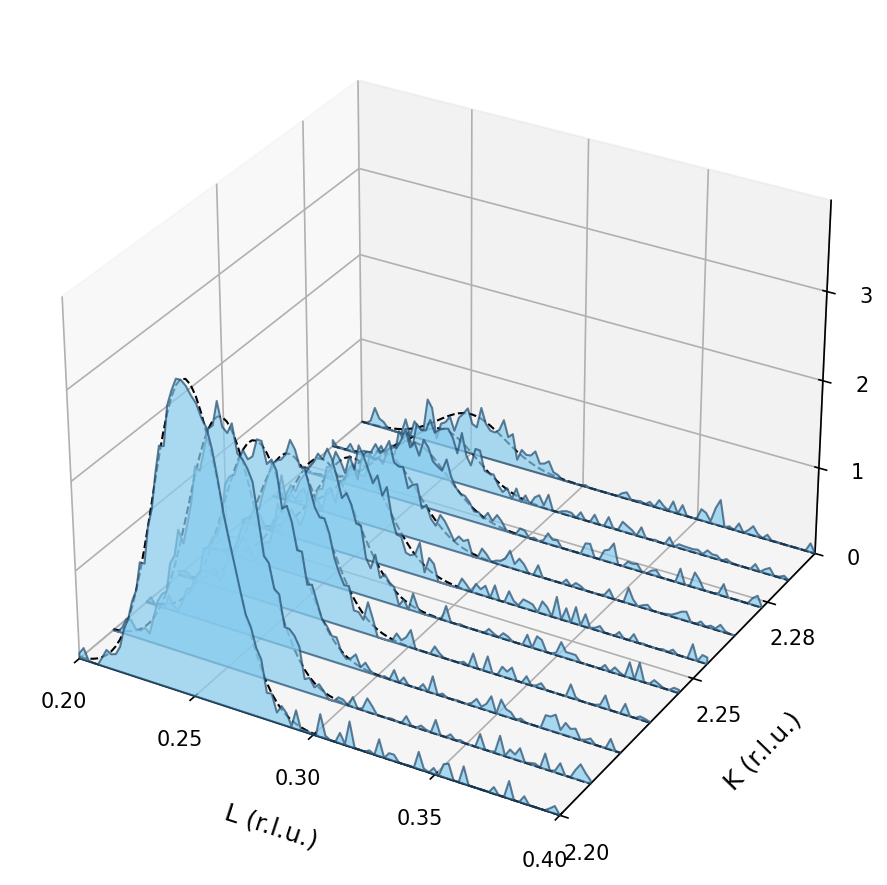

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection

# --- Data Simulation ---
# L axis (X): 0.20 to 0.40
l_vals = np.linspace(0.20, 0.40, 100)
# K axis (Y): Discrete slices 2.2, 2.21, ... 2.3
k_slices = np.linspace(2.20, 2.30, 10)

def peak_profile(l, k_val):
    # Peak centered at L=0.25?
    # Intensity decreases as K increases away from Bragg peak?
    # Or maybe it's a rod.
    # From image: Peak at L~0.25. Height decreases as K increases (2.2 -> 2.3).
    center_l = 0.25
    width_l = 0.015
    
    # Height decay
    # Max height at K=2.2
    max_h = 3.5
    decay = np.exp(-(k_val - 2.20)/0.05)
    height = max_h * decay
    
    # Gaussian/Lorentzian
    y = height * np.exp(-((l - center_l)**2) / (2 * width_l**2))
    
    # Add noise
    y += np.random.normal(0, 0.1, len(l))
    y = np.maximum(0, y) # No negative intensity
    return y

# Generate polygons for 3D plot
verts = []
zs = []
for k in k_slices:
    y = peak_profile(l_vals, k)
    # Add fit line (dashed) - smoothened
    y_fit = peak_profile(l_vals, k) # Actually just using same function without noise for fit
    # Let's store raw data for poly
    
    # Close polygon: (min,0), (x,y), (max,0)
    v = [(l_vals[0], 0)] + list(zip(l_vals, y)) + [(l_vals[-1], 0)]
    verts.append(v)
    zs.append(k)

# --- Plotting ---
fig = plt.figure(figsize=(8, 6), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# PolyCollection
poly = PolyCollection(verts, facecolors='#88CCEE', edgecolors='#204a6e', alpha=0.7)
ax.add_collection3d(poly, zs=zs, zdir='y')

# Add Dashed Fit Lines (Plot manually on top)
for k in k_slices:
    # Smooth fit
    y_fit = 3.5 * np.exp(-(k - 2.20)/0.05) * np.exp(-((l_vals - 0.25)**2) / (2 * 0.015**2))
    ax.plot(l_vals, np.full_like(l_vals, k), y_fit, 'k--', lw=1, zdir='z')

# Limits
ax.set_xlim3d(0.20, 0.40)
ax.set_ylim3d(2.20, 2.30)
ax.set_zlim3d(0, 4)

# Labels
ax.set_xlabel('L (r.l.u.)', fontsize=12, labelpad=10)
ax.set_ylabel('K (r.l.u.)', fontsize=12, labelpad=10)
ax.set_zlabel('Intensity (arb. units)', fontsize=12, labelpad=10)

# View
ax.view_init(elev=30, azim=-60)

# Ticks
ax.set_xticks([0.20, 0.25, 0.30, 0.35, 0.40])
ax.set_yticks([2.2, 2.25, 2.28]) # Custom spacing?
ax.set_zticks([0, 1, 2, 3])

plt.tight_layout()
plt.show()
